# 02 EDA Main

## 1. Data

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
ROOT = Path.cwd().resolve().parent

Q8_PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_cycle3_q8_processed_only.csv"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ------------------------------------------------------------
# Load processed-only data
# ------------------------------------------------------------
analysis = pd.read_csv(Q8_PROCESSED_PATH)

required_cols = [
    "sad_binary",
    "sad_group",
    "smoker_binary",
    "current_cigarette_status",
    "smoking_freq_group"
]

missing_cols = [col for col in required_cols if col not in analysis.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Please rerun 01_DataCheck.ipynb first.")

analysis["sad_binary"] = analysis["sad_binary"].astype(int)
analysis["smoker_binary"] = analysis["smoker_binary"].astype(int)

print("Rows valid for Q8 analysis:", len(analysis))

Rows valid for Q8 analysis: 13174


## 2. Group Summary

In [7]:
summary = (
    analysis
    .groupby(["sad_binary", "sad_group"], as_index=False)
    .agg(
        n=("smoker_binary", "count"),
        current_cigarette_users=("smoker_binary", "sum"),
        current_cigarette_proportion=("smoker_binary", "mean")
    )
)

summary["current_cigarette_percent"] = summary["current_cigarette_proportion"] * 100
summary = summary.sort_values("sad_binary", ascending=False).reset_index(drop=True)

summary.to_csv(TAB_DIR / "02_group_summary.csv", index=False)
display(summary)

,sad_binary,sad_group,n,current_cigarette_users,current_cigarette_proportion,current_cigarette_percent
0,1,Sad/Hopeless: Yes,3854,1064,0.2761,27.6077
1,0,Sad/Hopeless: No,9320,1508,0.1618,16.1803


## 3. Visualization 1: Proportion Gap Plot

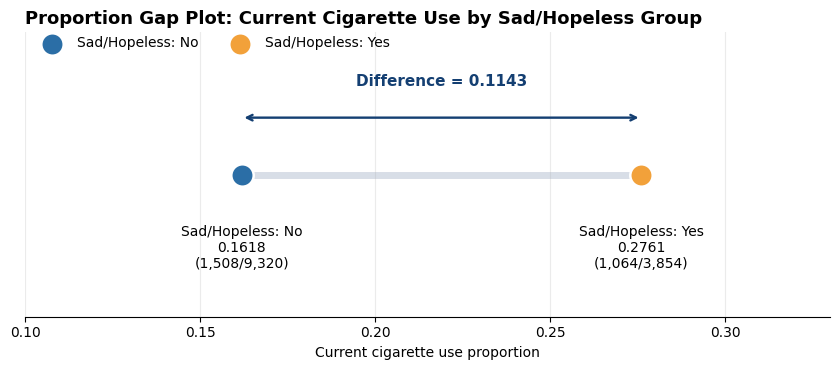

In [8]:
# ------------------------------------------------------------
# Proportion gap plot: p_yes vs p_no
# ------------------------------------------------------------

p_yes = float(summary.loc[summary["sad_binary"] == 1, "current_cigarette_proportion"].iloc[0])
p_no = float(summary.loc[summary["sad_binary"] == 0, "current_cigarette_proportion"].iloc[0])
n_yes = int(summary.loc[summary["sad_binary"] == 1, "n"].iloc[0])
n_no = int(summary.loc[summary["sad_binary"] == 0, "n"].iloc[0])
x_yes = int(summary.loc[summary["sad_binary"] == 1, "current_cigarette_users"].iloc[0])
x_no = int(summary.loc[summary["sad_binary"] == 0, "current_cigarette_users"].iloc[0])
diff = p_yes - p_no

fig, ax = plt.subplots(figsize=(8.5, 3.8))

# Horizontal gap line
ax.plot([p_no, p_yes], [0, 0], linewidth=5, solid_capstyle="round", color="#d8dee7", zorder=1)

# Endpoints
ax.scatter(p_no, 0, s=260, color="#2b6ea6", edgecolor="white", linewidth=1.8, zorder=3, label="Sad/Hopeless: No")
ax.scatter(p_yes, 0, s=260, color="#f2a13a", edgecolor="white", linewidth=1.8, zorder=3, label="Sad/Hopeless: Yes")

# Difference arrow and label
ax.annotate(
    "",
    xy=(p_yes, 0.18),
    xytext=(p_no, 0.18),
    arrowprops=dict(arrowstyle="<->", color="#143f72", linewidth=1.7)
)
ax.text(
    (p_yes + p_no) / 2,
    0.27,
    f"Difference = {diff:.4f}",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    color="#143f72"
)

# Labels
ax.text(p_no, -0.16, f"Sad/Hopeless: No\n{p_no:.4f}\n({x_no:,}/{n_no:,})", ha="center", va="top", fontsize=10)
ax.text(p_yes, -0.16, f"Sad/Hopeless: Yes\n{p_yes:.4f}\n({x_yes:,}/{n_yes:,})", ha="center", va="top", fontsize=10)

ax.set_title("Proportion Gap Plot: Current Cigarette Use by Sad/Hopeless Group", fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Current cigarette use proportion")
ax.set_yticks([])
ax.set_xlim(0.10, 0.33)
ax.set_ylim(-0.45, 0.45)
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="upper left", bbox_to_anchor=(0, 1.03), ncol=2, frameon=False)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / "02_current_cigarette_use_proportion_gap.png", dpi=300, bbox_inches="tight")
plt.show()

#### Interpretation

This proportion gap plot highlights the difference between the two groups. The current cigarette use proportion was **0.2761** in the **Sad/Hopeless: Yes** group and **0.1618** in the **Sad/Hopeless: No** group.

The estimated gap was **0.1143**, suggesting that students who felt sad or hopeless had a noticeably higher current cigarette use proportion in the sample.

## 4. Visualization 2: Binary Smoking Status Distribution

,sad_group,current_cigarette_status,count,within_group_percent
0,Sad/Hopeless: No,Non-smoker,7812,83.8000
1,Sad/Hopeless: Yes,Non-smoker,2790,72.4000
2,Sad/Hopeless: No,Current smoker,1508,16.2000
3,Sad/Hopeless: Yes,Current smoker,1064,27.6000


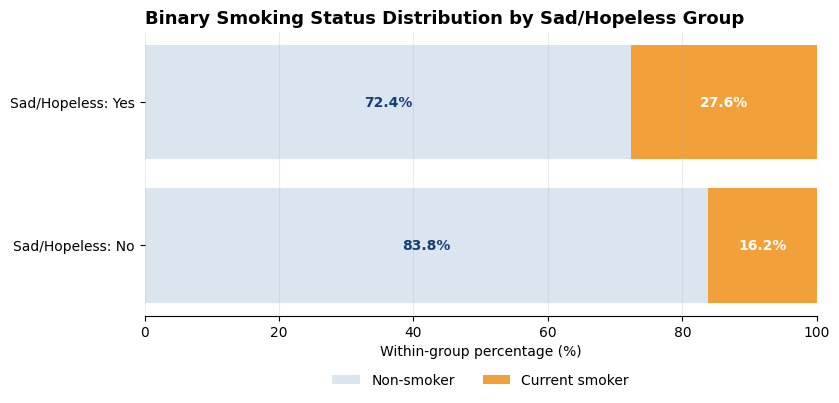

In [9]:
# ------------------------------------------------------------
# Binary smoking status distribution: Non-smoker vs Current smoker
# ------------------------------------------------------------

group_order = ["Sad/Hopeless: No", "Sad/Hopeless: Yes"]
status_order = ["Non-smoker", "Current smoker"]

status_counts = (
    pd.crosstab(
        analysis["sad_group"],
        analysis["current_cigarette_status"]
    )
    .reindex(index=group_order, columns=status_order, fill_value=0)
    .fillna(0)
    .astype(int)
)

status_props = (
    pd.crosstab(
        analysis["sad_group"],
        analysis["current_cigarette_status"],
        normalize="index"
    )
    .reindex(index=group_order, columns=status_order, fill_value=0)
    .fillna(0) * 100
)

status_table = (
    status_counts
    .reset_index()
    .melt(id_vars="sad_group", var_name="current_cigarette_status", value_name="count")
)

status_props_long = (
    status_props
    .reset_index()
    .melt(id_vars="sad_group", var_name="current_cigarette_status", value_name="within_group_percent")
)

status_table = status_table.merge(
    status_props_long,
    on=["sad_group", "current_cigarette_status"]
)

status_table["within_group_percent"] = status_table["within_group_percent"].round(1)
status_table.to_csv(TAB_DIR / "02_binary_smoking_status_distribution_by_sad_group.csv", index=False)
display(status_table)

fig, ax = plt.subplots(figsize=(8.5, 4.2))

left = np.zeros(len(group_order))
colors = {
    "Non-smoker": "#dbe5ef",
    "Current smoker": "#f2a13a"
}
text_colors = {
    "Non-smoker": "#143f72",
    "Current smoker": "white"
}

for status in status_order:
    vals = status_props.loc[group_order, status].values
    bars = ax.barh(group_order, vals, left=left, color=colors[status], label=status)

    for i, val in enumerate(vals):
        if val >= 5:
            ax.text(
                left[i] + val / 2,
                i,
                f"{val:.1f}%",
                va="center",
                ha="center",
                fontsize=10,
                fontweight="bold",
                color=text_colors[status]
            )

    left += vals

ax.set_xlim(0, 100)
ax.set_xlabel("Within-group percentage (%)")
ax.set_title("Binary Smoking Status Distribution by Sad/Hopeless Group", fontsize=13, fontweight="bold", loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False)
ax.grid(axis="x", alpha=0.25)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / "02_binary_smoking_status_distribution_by_sad_group.png", dpi=300, bbox_inches="tight")
plt.show()

#### Interpretation

This 100% stacked bar chart shows the full binary smoking status distribution within each group. The **Sad/Hopeless: Yes** group had a larger current smoker segment and a smaller non-smoker segment than the **Sad/Hopeless: No** group.

This supports the same descriptive pattern as the proportion gap plot, but it shows the complete binary response distribution.

## 5. Visualization 3: Smokers-only Frequency Difference

,smoking_freq_group,sad_no_percent,sad_yes_percent,difference_pp_yes_minus_no
0,Light (1~5 days),45.6000,41.1000,-4.5000
1,Moderate (6~19 days),20.4000,21.7000,1.4000
2,Frequent (20~30 days),34.1000,37.2000,3.1000


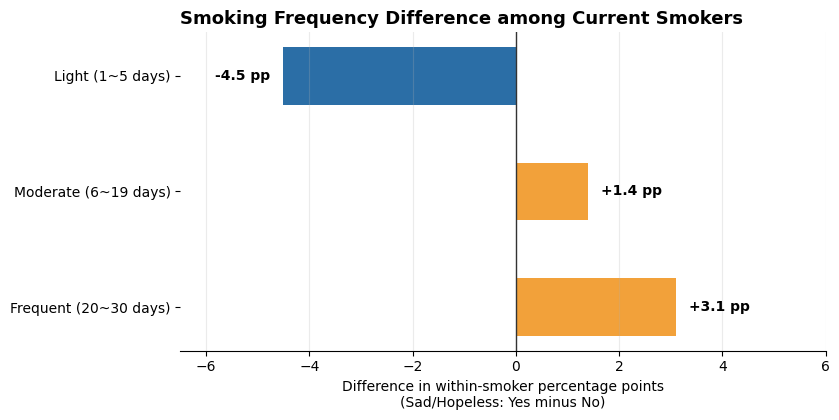

In [10]:
# ------------------------------------------------------------
# Smokers-only frequency difference plot
# Difference = Sad/Hopeless: Yes percent - Sad/Hopeless: No percent
# ------------------------------------------------------------

freq_order = [
    "Light (1~5 days)",
    "Moderate (6~19 days)",
    "Frequent (20~30 days)",
]

group_order = ["Sad/Hopeless: No", "Sad/Hopeless: Yes"]

smoker_only = analysis[
    (analysis["smoker_binary"] == 1) &
    (analysis["smoking_freq_group"].isin(freq_order))
].copy()

freq_counts = (
    pd.crosstab(
        smoker_only["sad_group"],
        smoker_only["smoking_freq_group"]
    )
    .reindex(index=group_order, columns=freq_order, fill_value=0)
    .fillna(0)
    .astype(int)
)

freq_props = (
    pd.crosstab(
        smoker_only["sad_group"],
        smoker_only["smoking_freq_group"],
        normalize="index"
    )
    .reindex(index=group_order, columns=freq_order, fill_value=0)
    .fillna(0) * 100
)

freq_diff_table = pd.DataFrame({
    "smoking_freq_group": freq_order,
    "sad_no_percent": [freq_props.loc["Sad/Hopeless: No", col] for col in freq_order],
    "sad_yes_percent": [freq_props.loc["Sad/Hopeless: Yes", col] for col in freq_order],
})

freq_diff_table["difference_pp_yes_minus_no"] = (
    freq_diff_table["sad_yes_percent"] - freq_diff_table["sad_no_percent"]
)

freq_diff_table = freq_diff_table.round(1)
freq_diff_table.to_csv(TAB_DIR / "02_smoking_frequency_difference_smokers_only.csv", index=False)
display(freq_diff_table)

# Plot as a diverging difference plot
fig, ax = plt.subplots(figsize=(8.5, 4.3))

y = np.arange(len(freq_diff_table))
diffs = freq_diff_table["difference_pp_yes_minus_no"].values
colors = ["#f2a13a" if val > 0 else "#2b6ea6" for val in diffs]

ax.axvline(0, color="#333333", linewidth=1)
ax.barh(y, diffs, color=colors, height=0.5)

for i, val in enumerate(diffs):
    ha = "left" if val >= 0 else "right"
    x_text = val + 0.25 if val >= 0 else val - 0.25
    ax.text(
        x_text,
        i,
        f"{val:+.1f} pp",
        va="center",
        ha=ha,
        fontsize=10,
        fontweight="bold"
    )

ax.set_yticks(y)
ax.set_yticklabels(freq_diff_table["smoking_freq_group"])
ax.invert_yaxis()
ax.set_xlabel("Difference in within-smoker percentage points\n(Sad/Hopeless: Yes minus No)")
ax.set_title("Smoking Frequency Difference among Current Smokers", fontsize=13, fontweight="bold", loc="left")
ax.set_xlim(min(diffs.min() - 2, -6), max(diffs.max() + 2, 6))
ax.grid(axis="x", alpha=0.25)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / "02_smoking_frequency_difference_smokers_only.png", dpi=300, bbox_inches="tight")
plt.show()

#### Interpretation

This smokers-only difference plot compares the smoking frequency composition between the two groups. The **Sad/Hopeless: Yes** group had a lower share of light smokers but a higher share of moderate and frequent smokers.

Because this figure only includes current smokers, it should be interpreted as an exploratory description of smoking intensity among smokers, not as the main two-sample inference result.